In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
from utils import DataHandler, plot_closed_loop_forecast, closed_loop_predict_from_X_test
from ESN import ESNetwork, ClassicalRC
from tqdm import tqdm
from reservoirs import CPRC, GBPermanents

In [20]:
from joblib import Parallel, delayed

def run_for_window_size(w, n_samples=1000, tr=0.75, tau=17, forecast_steps=20):
    try:
        # Load dataset
        X, Y = DataHandler().load_dataset(
            'mackey_glass',
            n_samples=n_samples,
            tau=tau,
            window_size=w,
            prediction_horizon=1,
            plot=False
        )

        # Split train/test
        train_size = int(n_samples * tr)
        X_train_, X_test_ = X[:train_size], X[train_size:]
        y_train, y_test = Y[:train_size], Y[train_size:]

        # Normalize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_)
        X_test = scaler.transform(X_test_)

        # Model
        dim = len(X_train[0])
        CP_params = [0.1499956344663278, np.pi/7, -np.pi/3, 7*np.pi/7, np.pi/9, -np.pi/7]
        cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel=True)
        esn = ESNetwork(
            reservoir=cprc,
            dim=dim,
            regularization=1e-6,
            alpha=0.8,
            show_progress=False,
            approach='feedback',
            model_type='ridge',
            limit=0.6,
            cpk=True
        )

        esn.fit(X_train, y_train)
        preds = closed_loop_predict_from_X_test(esn, X_test, m=1, steps=forecast_steps)
        true_vals = y_test[:len(preds)]
        rmse_t = np.abs(preds - true_vals)
        nrmse_t = rmse_t / np.std(y_test)

        return w, nrmse_t

    except Exception as e:
        return w, f"Error: {e}"


In [21]:
window_sizes = list(range(3, 13, 3))

# Use tqdm with joblib
from joblib import parallel_backend

with parallel_backend("loky", n_jobs=-1):
    results = Parallel()(delayed(run_for_window_size)(w) for w in tqdm(window_sizes))


Closed-loop Prediction: 100%|██████████| 20/20 [00:00<00:00, 37.87it/s]


In [22]:
rmse_over_time = {w: rmse for w, rmse in results if isinstance(rmse, np.ndarray)}
errors = {w: err for w, err in results if isinstance(err, str)}

# Optional: check if any runs failed
if errors:
    print("Some runs failed:")
    for w, msg in errors.items():
        print(f"Window size {w}: {msg}")


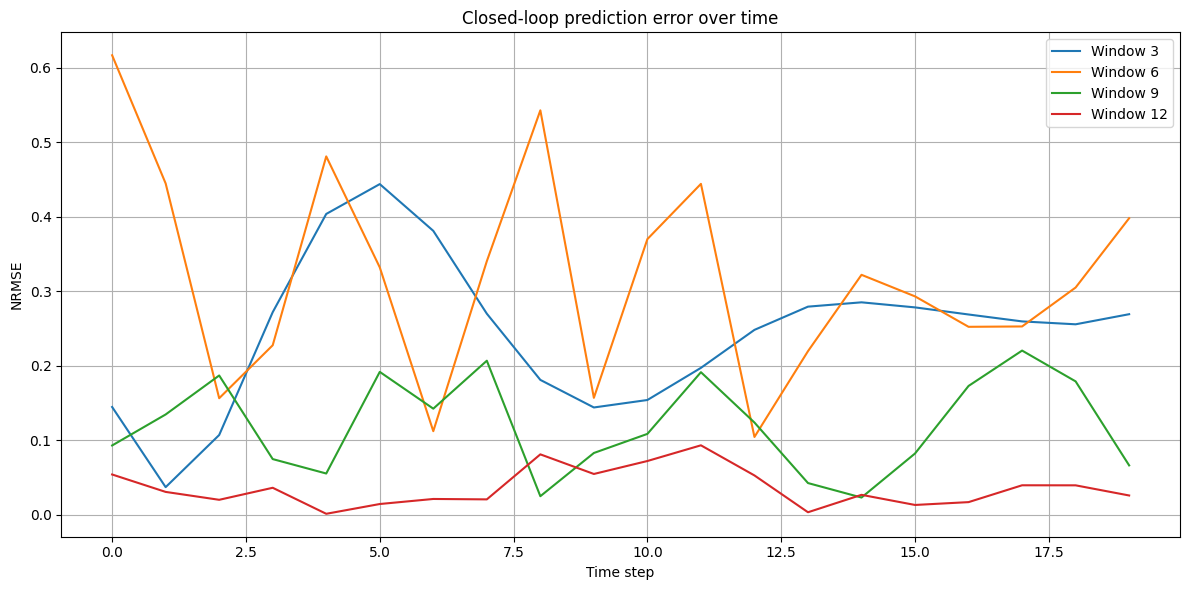

In [23]:
plt.figure(figsize=(12, 6))
for w, errors in rmse_over_time.items():
    plt.plot(errors[0:50], label=f'Window {w}')
plt.xlabel("Time step")
plt.ylabel("NRMSE")
plt.title("Closed-loop prediction error over time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

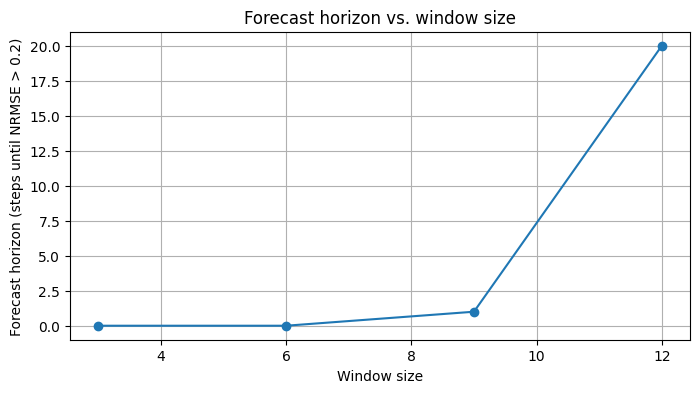

In [24]:
threshold = 0.1
horizons = []
for w, errors in rmse_over_time.items():
    above_thresh = np.where(errors > threshold)[0]
    if len(above_thresh) == 0:
        horizon = len(errors)
    else:
        horizon = above_thresh[0]
    horizons.append(horizon)

plt.figure(figsize=(8, 4))
plt.plot(window_sizes, horizons, marker='o')
plt.xlabel("Window size")
plt.ylabel("Forecast horizon (steps until NRMSE > 0.2)")
plt.title("Forecast horizon vs. window size")
plt.grid(True)
# plt.savefig("forecast_horizon.pdf")
plt.show()

In [25]:
reliable_horizon = {}
threshold = 0.2  # NRMSE threshold for acceptable forecast

for w, nrmse_t in rmse_over_time.items():
    # Find the first time step where NRMSE exceeds the threshold
    above_threshold = np.where(nrmse_t > threshold)[0]
    print(above_threshold)
    if len(above_threshold) == 0:
        reliable_horizon[w] = len(nrmse_t)  # Full length is reliable
    else:
        reliable_horizon[w] = above_threshold[0]  # First failure point

print(rmse_over_time.items())

[ 3  4  5  6  7 12 13 14 15 16 17 18 19]
[ 0  1  3  4  5  7  8 10 11 13 14 15 16 17 18 19]
[ 7 17]
[]
dict_items([(3, array([0.14442793, 0.03679124, 0.10680029, 0.27174535, 0.40365205,
       0.44374742, 0.38094925, 0.26973031, 0.18081523, 0.14378004,
       0.15381195, 0.19697924, 0.24799029, 0.27917927, 0.2849756 ,
       0.27817812, 0.26863549, 0.25935924, 0.25546845, 0.26903294])), (6, array([0.61675353, 0.44460817, 0.156188  , 0.22733085, 0.48093138,
       0.33193446, 0.11193593, 0.34019334, 0.5427953 , 0.15672075,
       0.36989348, 0.44406465, 0.10418475, 0.21939037, 0.32191951,
       0.29295596, 0.25209367, 0.25257765, 0.30485423, 0.39792565])), (9, array([0.09274444, 0.13439611, 0.18673484, 0.07447348, 0.0550966 ,
       0.19156864, 0.14217774, 0.20656222, 0.02463298, 0.08265079,
       0.1083052 , 0.19114385, 0.12356175, 0.04227856, 0.02283389,
       0.08200163, 0.17269418, 0.22018199, 0.17881256, 0.06599419])), (12, array([0.05379574, 0.03039134, 0.01979102, 0.03593897, 0

[np.int64(3), np.int64(0), np.int64(7), 20]


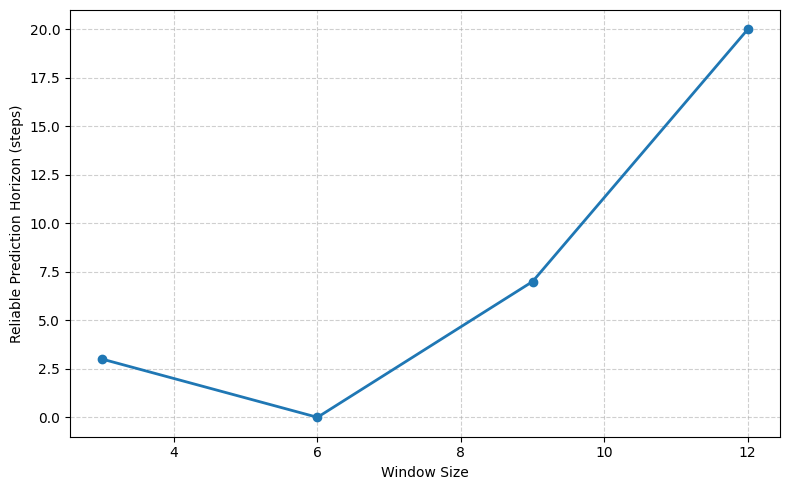

In [26]:
window_sizes = sorted(reliable_horizon.keys())
horizons = [reliable_horizon[w] for w in window_sizes]
print(horizons)
plt.figure(figsize=(8, 5))
plt.plot(window_sizes, horizons, marker='o', linewidth=2)
plt.xlabel("Window Size")
plt.ylabel("Reliable Prediction Horizon (steps)")
# plt.title("Forecast Horizon vs Window Size (NRMSE ≤ 0.2)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("forecast_horizon.pdf")
plt.show()

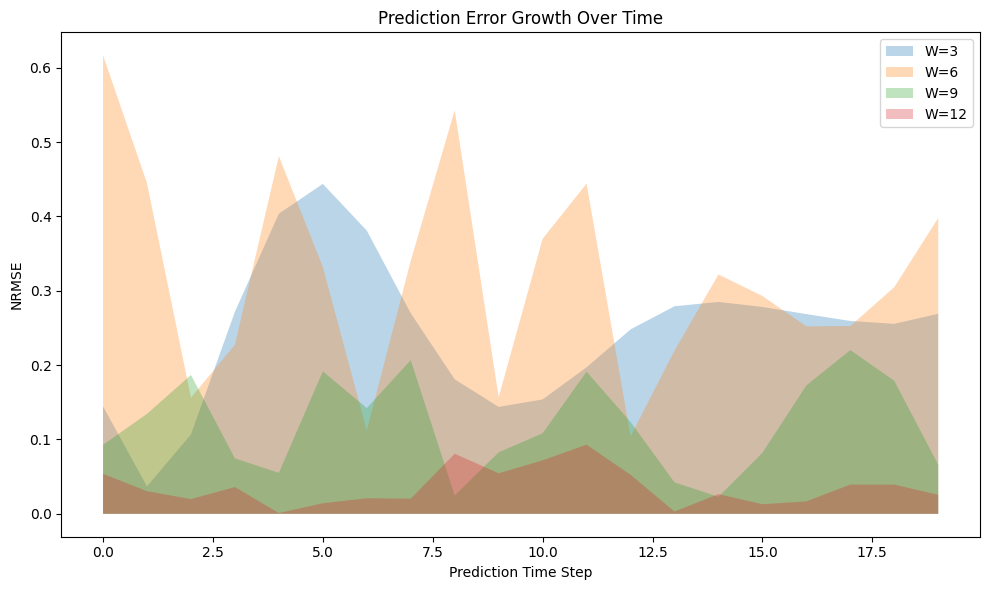

In [27]:
plt.figure(figsize=(10, 6))
for w in window_sizes:
    plt.fill_between(range(len(rmse_over_time[w][:200])), 0, rmse_over_time[w][:200], alpha=0.3, label=f"W={w}")

plt.xlabel("Prediction Time Step")
plt.ylabel("NRMSE")
plt.title("Prediction Error Growth Over Time")
plt.legend()
plt.tight_layout()
plt.show()


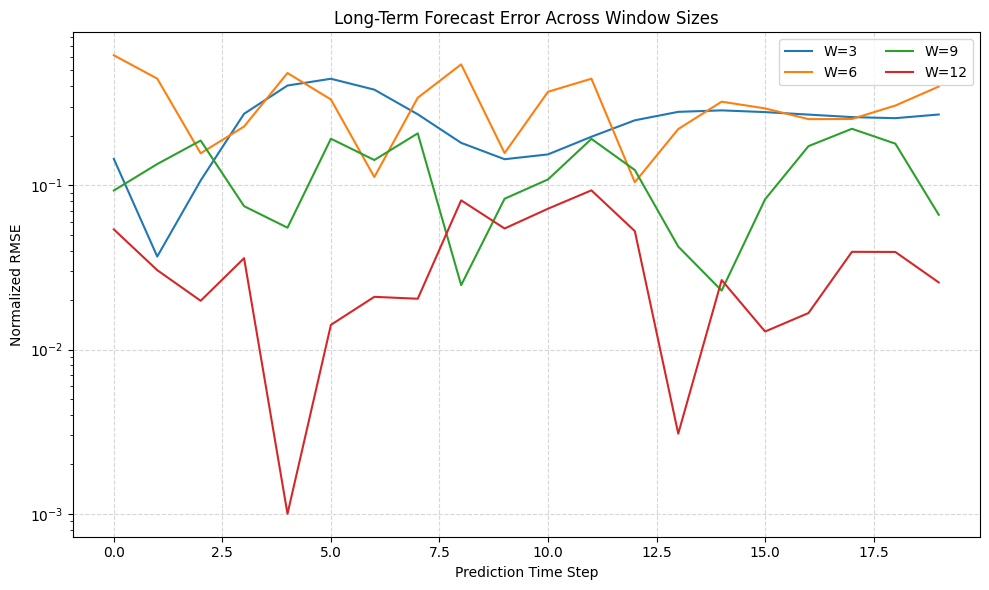

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
selected_ws = window_sizes  # or just use all keys
for w in selected_ws:
    plt.plot(rmse_over_time[w][:200], label=f"W={w}")

plt.xlabel("Prediction Time Step")
plt.ylabel("Normalized RMSE")
plt.yscale("log")  # Optional, if differences are large
plt.title("Long-Term Forecast Error Across Window Sizes")
plt.legend(ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("rmse_long_term.pdf")
plt.show()


In [33]:
tr=0.75
n_samples=1000
w=9
X, Y = DataHandler().load_dataset(
            'mackey_glass',
            n_samples=n_samples,
            tau=17,
            window_size=w,
            prediction_horizon=1,
            plot=False
        )

# Split train/test
train_size = int(n_samples * tr)
X_train_, X_test_ = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

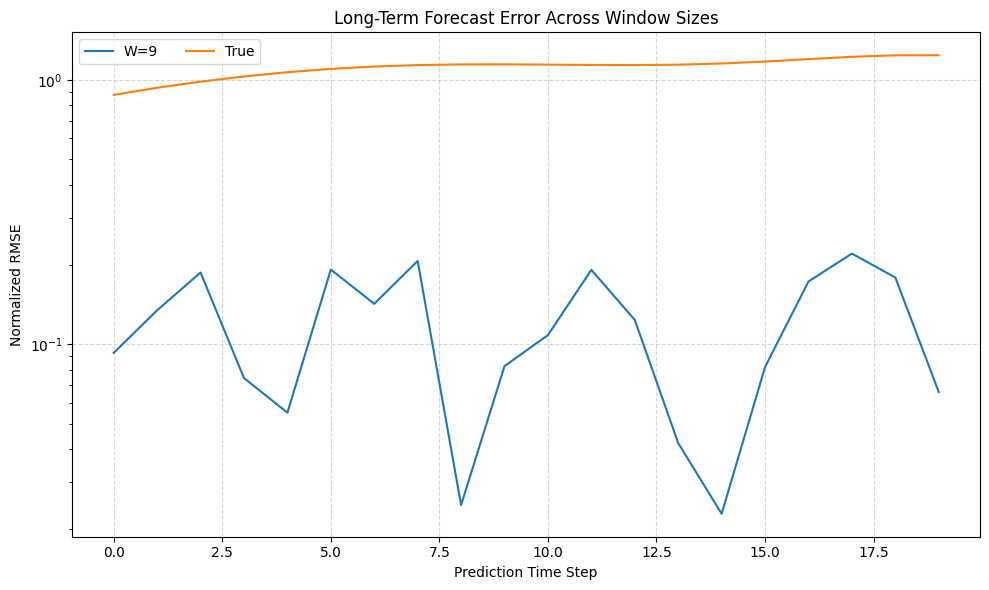

In [34]:
plt.figure(figsize=(10, 6))
selected_ws = window_sizes  # or just use all keys
plt.plot(rmse_over_time[w][:20], label=f"W={w}")
plt.plot(y_test[:20], label="True")

plt.xlabel("Prediction Time Step")
plt.ylabel("Normalized RMSE")
plt.yscale("log")  # Optional, if differences are large
plt.title("Long-Term Forecast Error Across Window Sizes")
plt.legend(ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("rmse_long_term.pdf")
plt.show()
